# Findings 

- when an action leads to collide to the wall, it does nothing (stays in the same position before the action). 

- dot can't get inside nor penetrate through the wall.  

- env is not aware of the dot to be a blob, rather it treates it as a dot. 

- that's why you might (visually) see the blog to be inside the wall.

- last state is discarded to match the action shape. 

- location[t+1] = location[t] + action[t]

- training model never sees `locations`, it's privileged ground truth. 

- the encoder gets intensities (pixel values) and must invert the rendering to recover the coordinate. If locations were literally embedded in the pixel values, decoding them would be a lookup, not representation learning.

In [2]:
from pathlib import Path 
import random
import matplotlib.pyplot as plt 
import numpy as np
import torch
import yaml 

from eb_jepa.datasets.utils import init_data

# all plotting code lives in plots.py (same folder as this notebook)
from plots import (
    DOT_CHANNEL,
    WALL_CHANNEL,
    plot_channels,
    plot_dot_wall_overlay,
    plot_frame_grid,
    animate_frames,
    plot_trajectory_time_colored,
    plot_locations,
    animate_locations,
    plot_actions,
    animate_actions,
    plot_wall_layout,
    plot_obs_gallery,
    plot_obs_with_position,
)

# torch.manual_seed(0); np.random.seed(0); random.seed(0)

# Training (Upstream) related Data 

### `init_data` using `train.yaml`

`train_yaml` --> `loader`, `val_loader`, `data_config`

In [3]:
CFG_PATH = Path.cwd().parent.parent / "cfgs" / "train.yaml"

with open(CFG_PATH) as f:
    cfg = yaml.safe_load(f)

cfg["data"]["num_workers"] = 0 
cfg
loader, val_loader, data_config = init_data(env_name=  "two_rooms", cfg_data=dict(cfg["data"]))

# see planning_exploration.ipynb for more details on data_config

In [4]:
data_config

WallDatasetConfig(size=100000, val_size=10000, batch_size=384, dot_std=1.3, action_noise=1, action_angle_noise=0.2, action_step_mean=1.0, action_step_std=0.4, action_lower_bd=0.2, action_upper_bd=1.8, max_step=1, n_steps=91, img_size=65, train=True, device='cpu', repeat_actions=1, n_steps_reduce_factor=1, border_wall_loc=5, chunked_actions=False, normalize=True, fix_wall=False, fix_wall_batch_k=None, wall_padding=20, door_padding=10, wall_width=3, door_space=4, cross_wall_rate=0.35, expert_cross_wall_rate=0, wall_bump_rate=0.0, dup_traj_rate=0.0, expert_action_step_mean=0.9, expert_action_step_std=0, expert_action_lower_bd=0.9, expert_action_upper_bd=0.9, expert_traj_door_padding=2, exclude_wall_train='', exclude_door_train='', only_wall_val='', only_door_val='', fix_wall_location=32, fix_door_location=18, num_train_layouts=-1, image_based=True, sample_length=17)

In [5]:
print(data_config.size)  # total number of samples 
print(data_config.val_size)
print(data_config.batch_size)

100000
10000
384


In [6]:
print(len(loader))      # batch_size = 384
print(len(val_loader))  # batch_size = 4  

260
25000


In [7]:
loader.dataset.normalizer
val_loader.dataset.normalizer

In [8]:
# WallDataset generates a fresh random sample on every __getitem__ (the index is
# ignored), so re-seed right before sampling -> rerunning this cell always
# reproduces the same trajectory.
# SAMPLE_SEED = 0
# torch.manual_seed(SAMPLE_SEED); np.random.seed(SAMPLE_SEED); random.seed(SAMPLE_SEED)

batch = next(iter(loader))
val_batch = next(iter(val_loader))

# the data is generated on the fly, 
# the index is meaningless in context of different sample, 
# it only exists for DataLoader 

In [9]:
x, actions, locations, wall_x, door_y = batch

print(x.shape) # [B, C, T, H, W]
print(actions.shape)

# # this is what builds the dot channel in x. 
print(locations.shape)  

# There are logic for how thick is the wall size, and how large is the door in terms of pixels. (safely ignored)
print(wall_x.shape)
print(door_y.shape)


torch.Size([384, 2, 17, 65, 65])
torch.Size([384, 2, 17])
torch.Size([384, 2, 17])
torch.Size([384, 1])
torch.Size([384, 1])


In [10]:
val_x, val_actions, val_locations, val_wall_x, val_door_y = val_batch
print(val_x.shape)
print(val_actions.shape)
print(val_locations.shape)
print(val_wall_x.shape)
print(val_door_y.shape)

torch.Size([4, 2, 17, 65, 65])
torch.Size([4, 2, 17])
torch.Size([4, 2, 17])
torch.Size([4, 1])
torch.Size([4, 1])


In [11]:
# note you can also access states, actions..... as follow 

print(batch.states.shape)
print(batch.actions.shape)

torch.Size([384, 2, 17, 65, 65])
torch.Size([384, 2, 17])


# x (input frames)

- `x` is the normalized input (both channels, dot and wall)

- none of the plot functions in this section "unnormalize" the state. 

- dot is a Guassian blob 

In [12]:
sample_idx = 0 
dot_channel, wall_channel = DOT_CHANNEL, WALL_CHANNEL   # 0, 1
T = 0 

In [13]:
print(x[sample_idx, dot_channel, T].shape)
print(x[sample_idx, wall_channel, T].shape)

torch.Size([65, 65])
torch.Size([65, 65])


In [14]:
# the lower the number the darker, the higher the whiter. 

print(x[sample_idx, dot_channel, T].unique())
print("=="*50)
print(x[sample_idx, wall_channel, T].unique()) 


tensor([-0.0705,  0.0393,  0.1490,  0.2587,  0.3684,  0.6975,  0.9170,  1.0267,
         1.5753,  1.6850,  1.7947,  2.3433,  3.2210,  3.5501,  3.6598,  4.0987,
         4.2084,  4.8667,  5.0861,  5.5250,  7.1707,  7.4999,  8.0484,  8.3776,
         8.8164,  8.9261, 11.9982, 12.2176, 12.4370, 16.6062, 17.8130, 18.1422,
        19.8976, 20.2268, 24.2862, 27.0291])
tensor([-0.3312,  3.0177])


In [15]:
# a sample has constant wall_channel across different Time, (obviously)

print(torch.allclose(x[sample_idx, dot_channel, T],x[sample_idx, dot_channel, T+1])) 
print(torch.allclose(x[sample_idx, wall_channel, T],x[sample_idx, wall_channel, T+1]))

True
True


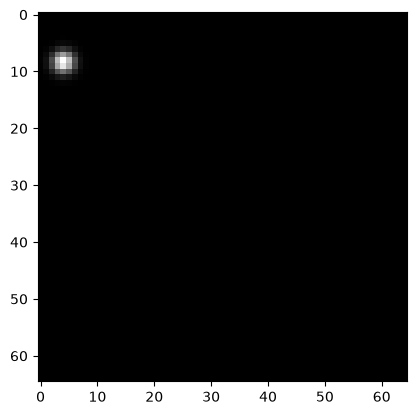

In [16]:
plt.imshow(x[sample_idx, dot_channel, T],cmap='gray')

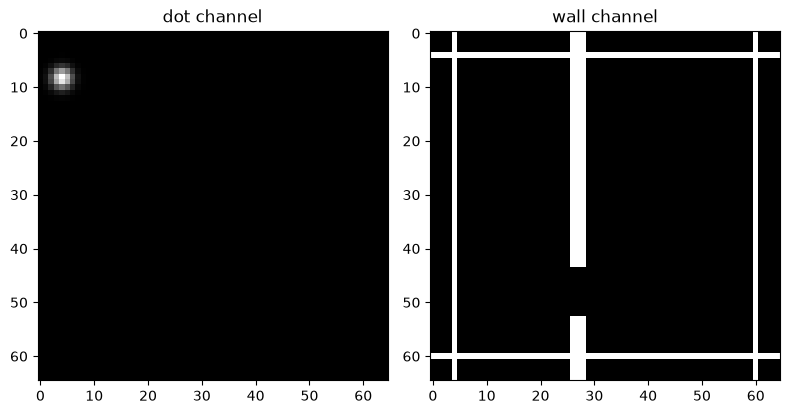

In [17]:
plot_channels(x, sample_idx, T) # function does not use "unnormalize"

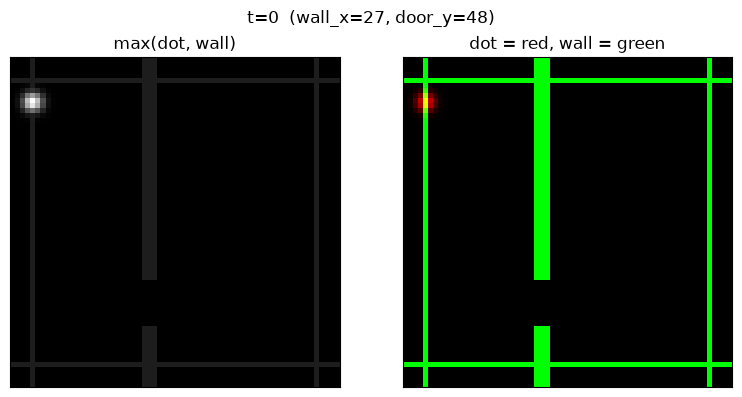

In [18]:
dot = batch.states[sample_idx, dot_channel]    # [T, 65, 65]
wall = batch.states[sample_idx, wall_channel]  # [T, 65, 65]
wx, dy = batch.wall_x[sample_idx].item(), batch.door_y[sample_idx].item()

plot_dot_wall_overlay(dot, wall, wx, dy, t=0)

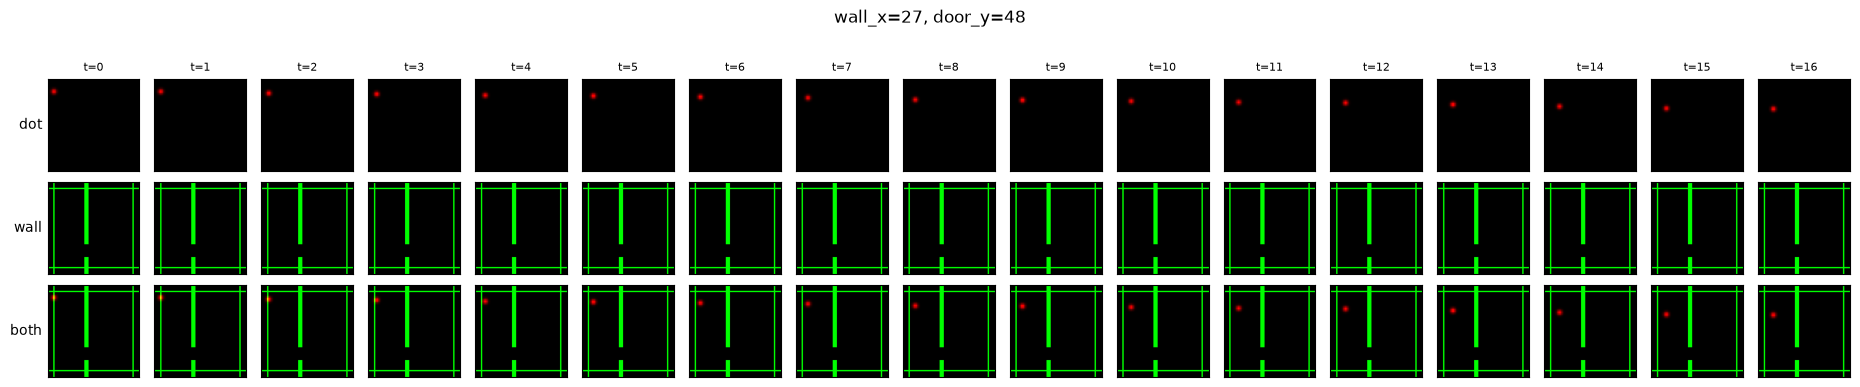

In [19]:
plot_frame_grid(dot, wall, wx, dy)

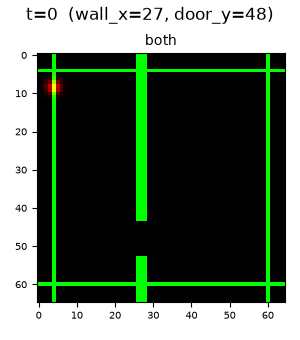

In [20]:
# same content as plot_frame_grid, but animated (writes dot.gif next to the notebook)
# both_only=True -> just the overlay; both_only=False -> dot / wall / both side by side
animate_frames(dot, wall, wx, dy, path="dot.gif", fps=4, both_only=True)

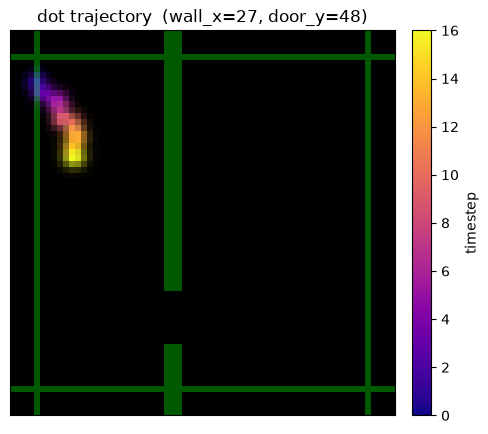

In [21]:
plot_trajectory_time_colored(dot, wall, wx, dy)

# locations 


- This is the normalized coordinate of (x,y) where the center of the dot trajectory is generated. 

In [22]:
print(locations.shape) 

torch.Size([384, 2, 17])


In [23]:
print(locations[sample_idx].shape)
print("=="*50)
print(locations[sample_idx])

torch.Size([2, 17])
tensor([[-1.7122, -1.7122, -1.6671, -1.6218, -1.5503, -1.4958, -1.4925, -1.4631,
         -1.4440, -1.4327, -1.3545, -1.3278, -1.3272, -1.3064, -1.3210, -1.3235,
         -1.3193],
        [-1.4715, -1.4715, -1.3972, -1.3605, -1.3062, -1.2808, -1.2345, -1.1968,
         -1.1124, -1.0943, -1.0495, -1.0034, -0.9753, -0.9023, -0.8184, -0.7340,
         -0.7093]])


In [24]:
locations[sample_idx,: , T] # (x,y) at timestep = 0 

tensor([-1.7122, -1.4715])

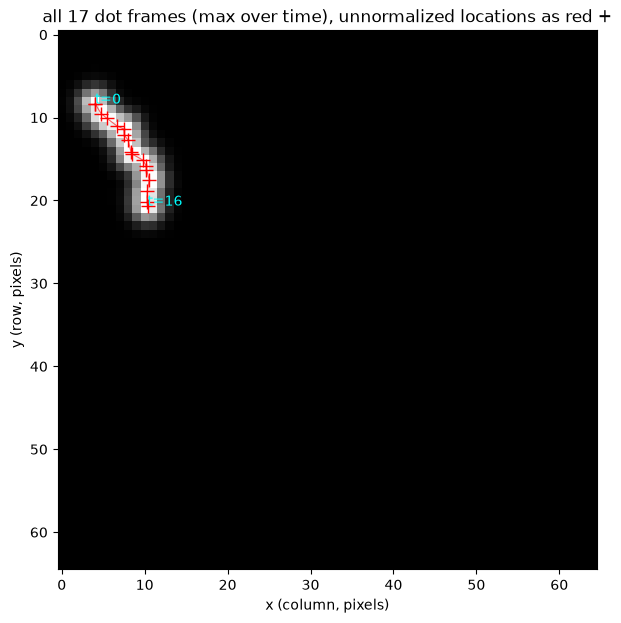

tensor([[ 4.0155,  8.3187],
        [ 4.0155,  8.3187],
        [ 4.7423,  9.5172],
        [ 5.4711, 10.1100],
        [ 6.6232, 10.9852],
        [ 7.4995, 11.3950],
        [ 7.5540, 12.1423],
        [ 8.0260, 12.7510],
        [ 8.3341, 14.1122],
        [ 8.5159, 14.4057],
        [ 9.7759, 15.1280],
        [10.2060, 15.8709],
        [10.2155, 16.3254],
        [10.5503, 17.5032],
        [10.3144, 18.8570],
        [10.2753, 20.2188],
        [10.3430, 20.6164]])


In [25]:
loc_px = plot_locations(x, locations, loader.dataset.normalizer, sample_idx)
print(loc_px)

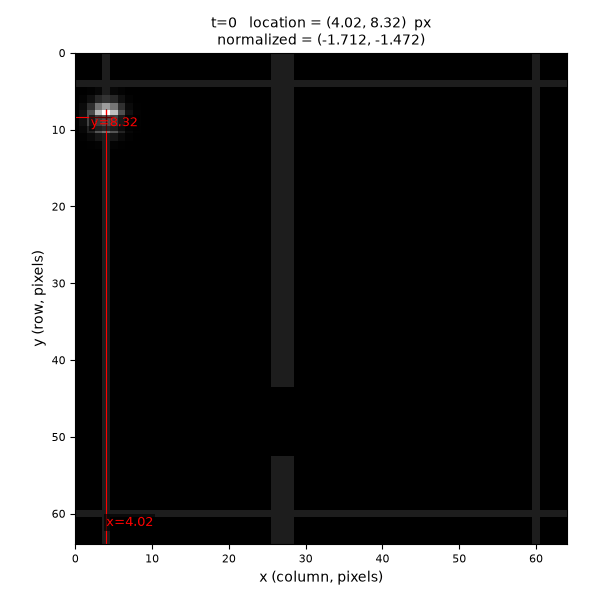

In [26]:
# same content as plot_locations, but animated (writes locations.gif next to the notebook)
# guides          -> red lines dropping to the x / y axes, with the value printed there
# show_normalized -> also print the raw normalized value stored in `locations`
# show_dot        -> the Gaussian blob (False = wall only, so the + is never buried in it)
# path_line       -> red dotted line through location[0..t]
animate_locations(
    x, locations, loader.dataset.normalizer, sample_idx,
    path="locations.gif", fps=4,
    guides=True, show_normalized=True, show_dot=True, path_line=True,
)


# actions 

- actions are not normalized, they stay in raw pixel. 

- What does the (x, y) mean? It's a displacement vector (Δx, Δy): "move Δx pixels horizontally and Δy pixels vertically this timestep.

- ‖(Δx, Δy)‖ ∈ [0.2, 1.8]

- sampling are blind to the walls. (they don't have knowledge of wall_x or door_y). 

In [27]:
# (B,A,T)

print(actions.shape)    # two channels refer to delta_x and delta_y 
actions[sample_idx] 

torch.Size([384, 2, 17])


tensor([[-0.8897,  0.7268,  0.7288,  1.1521,  0.8763,  0.0545,  0.4720,  0.3080,
          0.1819,  1.2600,  0.4301,  0.0095,  0.3348, -0.2359, -0.0390,  0.0677,
         -0.1792],
        [ 1.0931,  1.1985,  0.5928,  0.8752,  0.4098,  0.7473,  0.6087,  1.3613,
          0.2935,  0.7223,  0.7428,  0.4546,  1.1777,  1.3538,  1.3618,  0.3976,
          0.9386]])

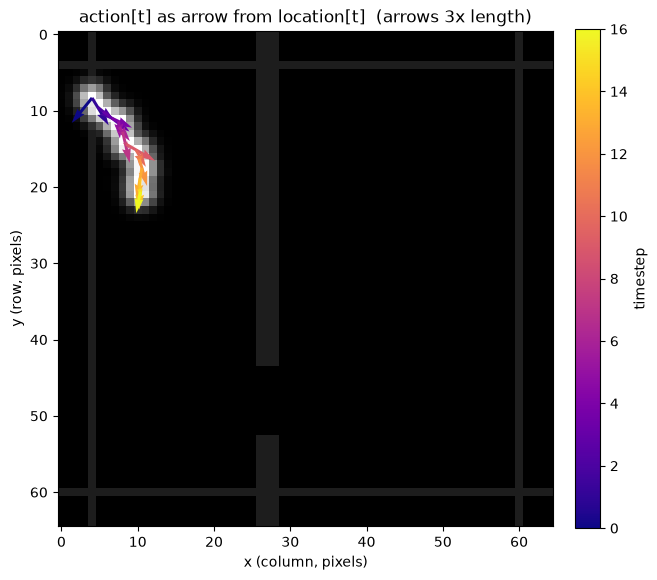

In [28]:
plot_actions(x, actions, locations, loader.dataset.normalizer, sample_idx, arrow_scale=3)

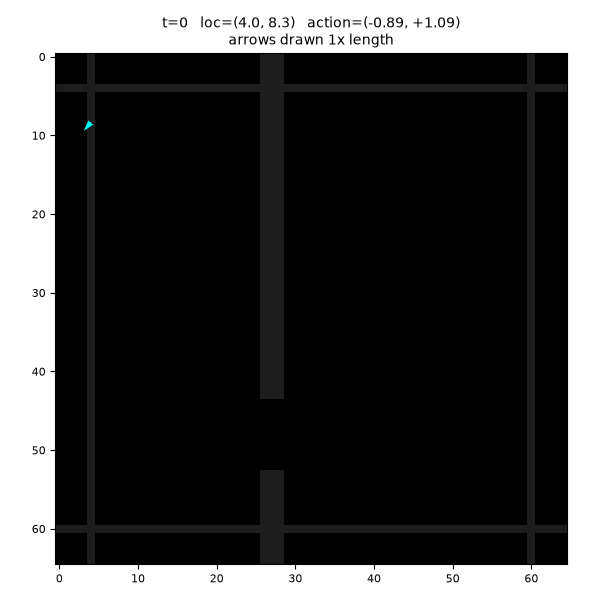

In [29]:
# same content as plot_actions, but animated (writes actions.gif next to the notebook)
# trail       -> past arrows stay faint (False = only the current arrow)
# show_dot    -> the Gaussian blob (False = wall only, arrows on an empty layout)
# show_marker -> white + at location[t]
# path_line   -> dotted line through location[0..t]
# cmap        -> "cool" / "autumn" / "spring" / "Wistia"  (avoid "plasma": starts dark purple)
animate_actions(
    x, actions, locations, loader.dataset.normalizer, sample_idx,
    path="actions.gif", fps=4, arrow_scale=1,
    trail=True, show_dot=False, show_marker=False, path_line=False, cmap="cool",
)

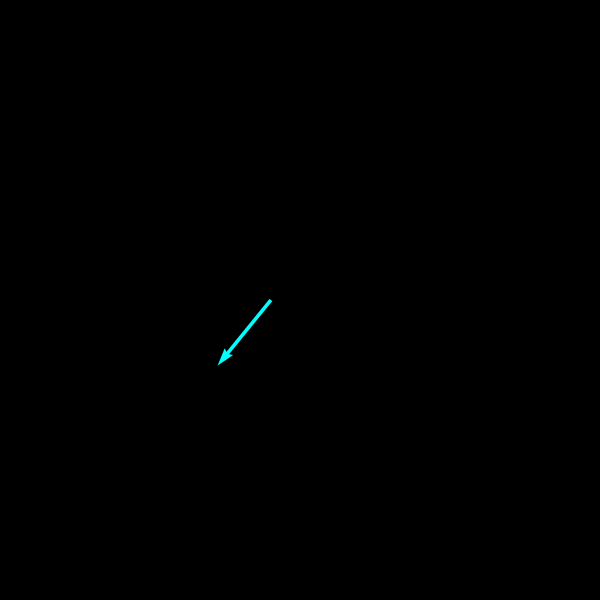

In [30]:
# same gif, but the camera follows the dot inside a 20x20 window of the 65x65 frame.
# nothing is rescaled -- the arrow is still arrow_scale * action pixels long, we
# just moved in close, which is what finally makes a ~1 px action readable.
# zoom       -> window side length in pixels (None = whole frame)
# zoom_clamp -> keep the window inside the image (dot drifts off-center at the edges)
# raw        -> no axes, no ticks, no title: image only, filling the whole gif
# show_wall  -> the wall channel (False = empty black canvas, arrows only)
animate_actions(
    x, actions, locations, loader.dataset.normalizer, sample_idx,
    path="actions_zoom.gif", fps=4, arrow_scale=1,
    trail=True, show_dot=False, show_wall=False, show_marker=False, path_line=False,
    cmap="cool", zoom=10, zoom_clamp=True, raw=True,
)

#  wall_x and door_y

- the size of the door comes from the door space (which is 4 in the config)

In [31]:
print(wall_x[sample_idx])   # the vertical line in to create the wall 
print(door_y[sample_idx])   # the gap in y axis 

tensor([27])
tensor([48])


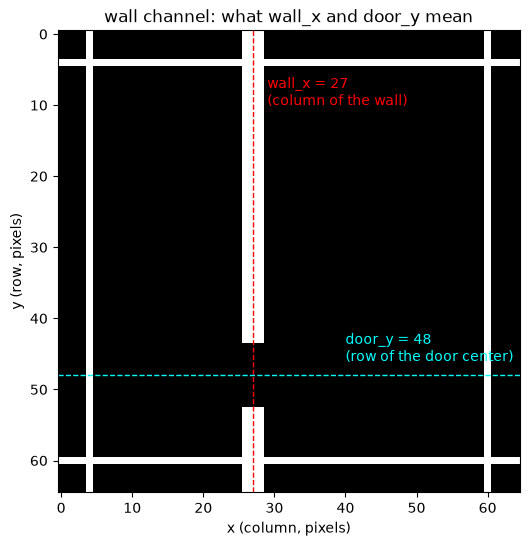

In [32]:
plot_wall_layout(x, wall_x, door_y, sample_idx)

# Eval (Downstream) related Data 

### env 

### `init` using `eval.yaml`

`eval.yaml` --> `env_config` --> for `env_creator` 

In [33]:
EVAL_CFG_PATH = Path.cwd().parent.parent / "cfgs" / "eval.yaml"

with open(EVAL_CFG_PATH, "r") as f:
    eval_cfg_dict = yaml.safe_load(f)

eval_cfg_dict

{'meta': {'num_eval_episodes': 20, 'plan_suffix': '_sum_diffs'},
 'env': {'n_allowed_steps': 200, 'level': 'normal'},
 'data': {'env_name': 'two_rooms'}}

In [34]:
from eb_jepa.datasets.utils import init_data
from eb_jepa.datasets.two_rooms.env import DotWall

# loader, val_loader, env_config
# notice, loader and val_loader are thrown away, since we already have them above.
_, _, env_config = init_data(
    env_name="two_rooms",
    cfg_data=dict(eval_cfg_dict.get("data",{})) # {'env_name' : 'two_rooms'}
)

env_config

WallDatasetConfig(size=100000, val_size=10000, batch_size=64, dot_std=1.3, action_noise=1, action_angle_noise=0.2, action_step_mean=1.0, action_step_std=0.4, action_lower_bd=0.2, action_upper_bd=1.8, max_step=1, n_steps=91, img_size=65, train=True, device='cpu', repeat_actions=1, n_steps_reduce_factor=1, border_wall_loc=5, chunked_actions=False, normalize=True, fix_wall=False, fix_wall_batch_k=None, wall_padding=20, door_padding=10, wall_width=3, door_space=4, cross_wall_rate=0.35, expert_cross_wall_rate=0, wall_bump_rate=0.0, dup_traj_rate=0.0, expert_action_step_mean=0.9, expert_action_step_std=0, expert_action_lower_bd=0.9, expert_action_upper_bd=0.9, expert_traj_door_padding=2, exclude_wall_train='', exclude_door_train='', only_wall_val='', only_door_val='', fix_wall_location=32, fix_door_location=18, num_train_layouts=-1, image_based=True, sample_length=17)

### `env_creator()`

In [35]:
cfg_eval_env = eval_cfg_dict.get("env")
cfg_eval_env

{'n_allowed_steps': 200, 'level': 'normal'}

In [36]:
def env_creator(): 
    cfg_eval_env = eval_cfg_dict.get("env")
    return DotWall(
        config=env_config, 
        **cfg_eval_env
    )

In [37]:
env = env_creator()
env

In [38]:
# error 
# env.step(np.zeros(2,))      # you can't take a step without first exectuing `reset`

In [39]:
obs, info = env.reset() # standard Gymnasium reset signature
print(obs.shape)

torch.Size([2, 65, 65])


### Obs 

In [40]:
print(f"obs.shape | {obs.shape} | dot and wall channels | raw pixel space")   
print(f'max value: {obs.max()}')

obs.shape | torch.Size([2, 65, 65]) | dot and wall channels | raw pixel space
max value: 255


### info 

In [41]:
for k,v in info.items(): 
    print(k)

dot_position
target_position
target_obs


In [42]:
info["dot_position"]    # unromalized coordinates, 

tensor([14.9094,  7.4396])

In [43]:
info["target_position"] # unromalized coordinates, 

tensor([45.1245, 47.9141])

In [44]:
print(info["target_obs"])
print(info["target_obs"].max())

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.uint8)
tensor(255, dtype=torch.uint8)


In [45]:
rows = [
    ("info dot position",    info["dot_position"].shape,    "raw pixel space"),  # agent current position, values between 0-65
    ("info target position", info["target_position"].shape, "raw pixel space"),  # agent target position, values between 0-65
    ("info target obs",      info["target_obs"].shape,      "raw pixel space"),  # image of the goal (dot placed at the target)
]

for label, shape, space in rows:
    print(f"{label:<22} | {str(shape):<24} | {space}")

info dot position      | torch.Size([2])          | raw pixel space
info target position   | torch.Size([2])          | raw pixel space
info target obs        | torch.Size([2, 65, 65])  | raw pixel space


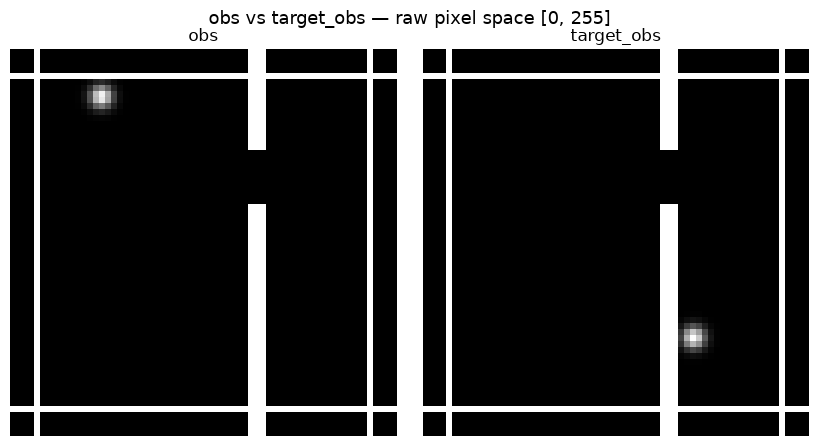

In [46]:
# which: "both" (default) | "obs" | "target"  -> one panel at a time
plot_obs_gallery(obs, info)

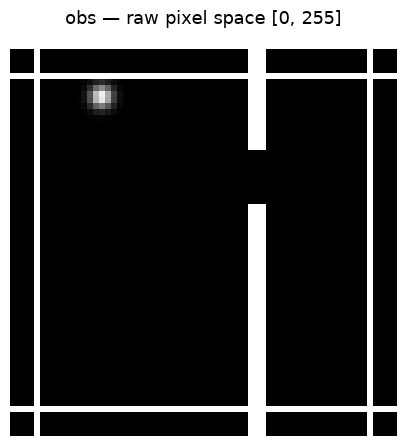

In [47]:
plot_obs_gallery(obs, info, which="obs")

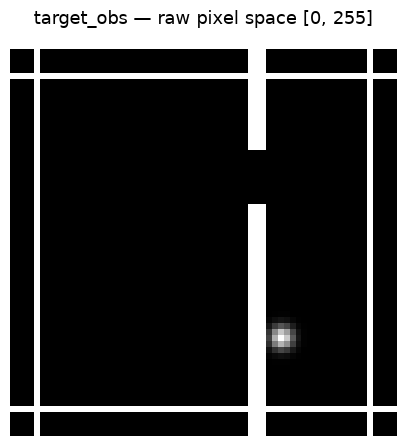

In [48]:
plot_obs_gallery(obs, info, which="target")

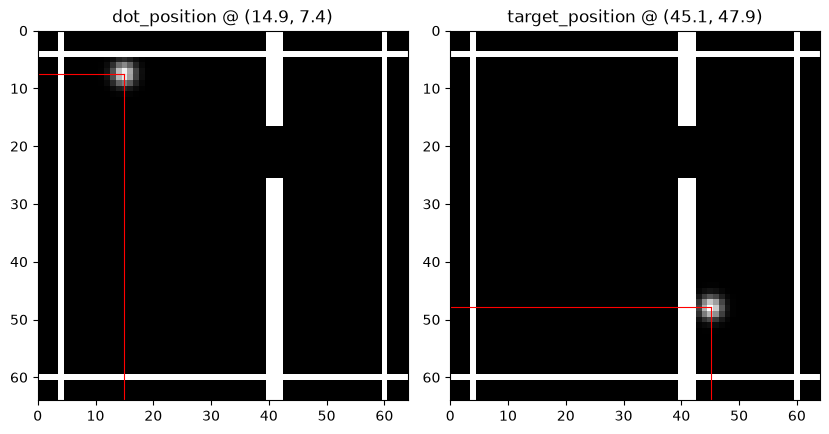

In [49]:
# which: "both" (default) | "obs" | "target"  -> one panel at a time
plot_obs_with_position(obs, info)

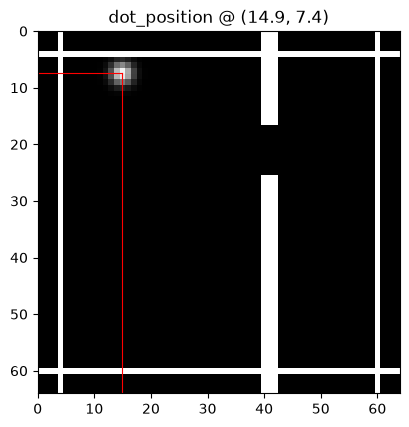

In [50]:
plot_obs_with_position(obs, info, which="obs")

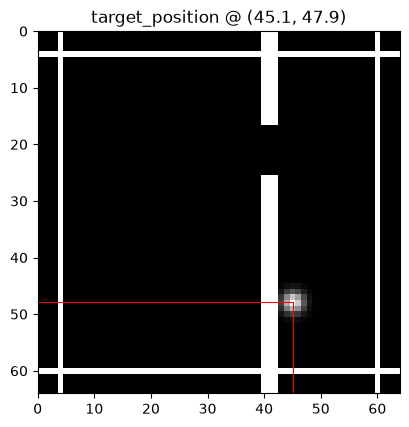

In [51]:
plot_obs_with_position(obs, info, which="target")

In [52]:
info["target_obs"]

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.uint8)

In [53]:
print(env.normalizer.normalize_state(info["target_obs"]).min())
print(env.normalizer.normalize_state(info["target_obs"]).max())

tensor(-0.3312)
tensor(27.0291)


### step

- `step` can only be executed after `rest`

- first input (actions we take) is zeros, so we get the state

- obvisouly, the target_position and target_obs are independed of action(s) and will remain the same through out an episdoe

In [54]:
env.reset()
obs, reward, done, truncated, info = env.step(np.zeros(env.action_space.shape[0])) # env.action_space.shape[0] : 2

print(obs.shape)
print(info["dot_position"].shape)
print(info["target_position"].shape)
print(info["target_obs"].shape)

torch.Size([2, 65, 65])
torch.Size([2])
torch.Size([2])
torch.Size([2, 65, 65])


In [55]:
obs2, reward, done, truncated, info2 = env.step(np.random.randn(2,))

In [56]:
print(torch.allclose(obs,obs2))
print(torch.allclose(info["target_obs"], info2["target_obs"]))
print(torch.allclose(info["target_position"], info2["target_position"]))

False
True
True


In [58]:
env.eval_state(info["target_position"], info["dot_position"])

{'success': np.False_, 'state_dist': np.float64(36.552449271306656)}